# Bright High-z Targets


No targets fall within a 3.6' NIRSpec MSA radius.


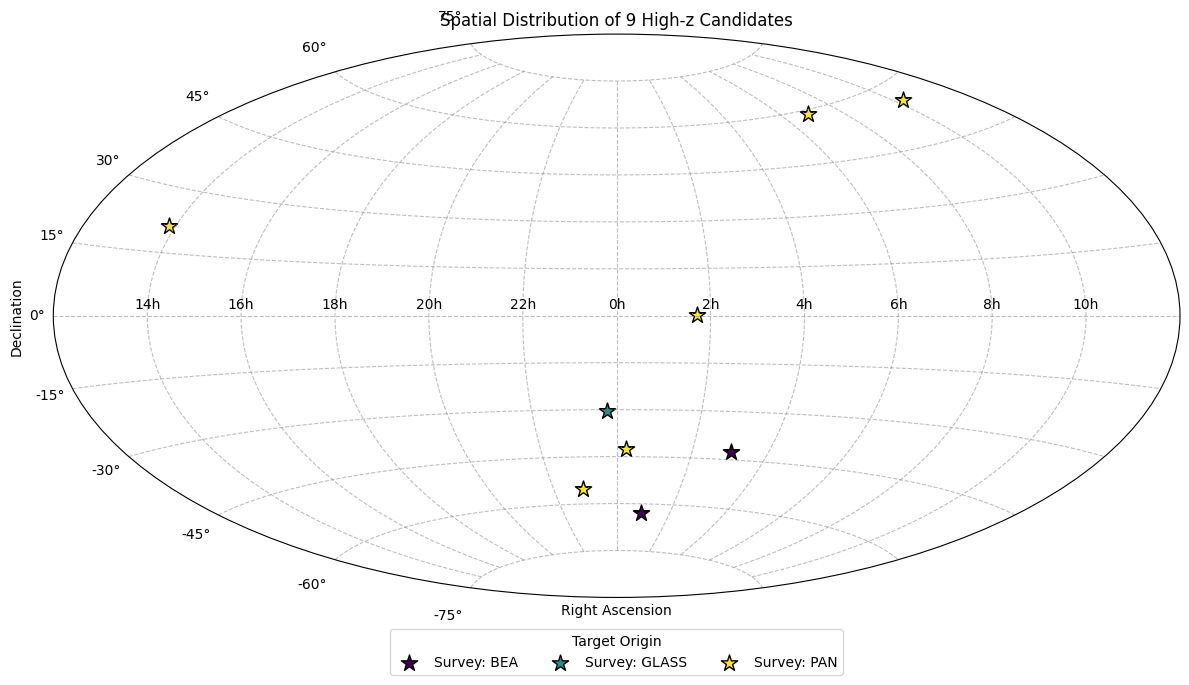

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import collections

# --- 1. Coordinate and Survey Data (Replace with your ~20 targets) ---

# Example target data (IDs, full strings, and originating survey)
targets_data = [
    ("PAN-0104-5508-2026296", "01:04:17.50 -55:07:35.55", "PAN"),
    ("PAN-1007+2109-2040861", "10:07:44.02 +21:11:00.98", "PAN"),
    ("PAN-1343+5549-2000350", "13:43:39.91 +55:46:45.76", "PAN"),
    ("PAN-1707+5852-2010068", "17:07:17.36 +58:51:11.06", "PAN"),
    ("BEA-2303-6250-2039802", "23:03:34.42 -62:50:11.26", "BEA"),
    ("GLASS-2039052", "00:13:59.75 -30:19:29.14", "GLASS"),
    ("BEA-2303-6250-2039802", "20:58:33.74 -42:44:08.61", "BEA"),
    ("PAN-2216+0024-3003658", "22:17:00.12 +00:22:44.69", "PAN"), 
    ("PAN-2345-4235-3022235", "23:45:15.45 -42:34:57.07", "PAN"), 
]

# Extract coordinates and surveys
coord_strings = [t[1] for t in targets_data]
survey_list = [t[2] for t in targets_data]

# Parse with Astropy
coords = SkyCoord(coord_strings, unit=(u.hourangle, u.deg), frame='icrs')

# Check for multipletarget pointings (MSA radius ~3.6 arcmin)
max_sep = 3.6 * u.arcmin
from astropy.coordinates import search_around_sky
idx1, idx2, sep2d, _ = search_around_sky(coords, coords, seplimit=max_sep)
unique_pairs = idx1 < idx2
matching_pairs = list(zip(idx1[unique_pairs], idx2[unique_pairs], sep2d[unique_pairs]))

# Identify pointings with multiples (using indices of targets with neighbors)
multiple_target_indices = set(idx1[unique_pairs]) | set(idx2[unique_pairs])

# --- 2. Map Categorization & Color Setup ---

# Get unique surveys and map colors
unique_surveys = sorted(list(set(survey_list)))
color_map_name = 'viridis' # 'Set1', 'Dark2', 'plasma' also good for categorization
cmap = plt.get_cmap(color_map_name, len(unique_surveys))
survey_colors = {survey: cmap(i) for i, survey in enumerate(unique_surveys)}

# Handle coordinate wrapping and radian conversion for Aitoff
# Center the map at RA=0 (wrapping at 180 deg)
ra_wrapped = coords.ra.wrap_at(180 * u.deg)
ra_rad = ra_wrapped.radian
dec_rad = coords.dec.radian

# --- 3. Plot Initialization (Aitoff) ---
fig = plt.figure(figsize=(12, 8))
ax = plt.subplot(111, projection='aitoff')
ax.grid(True, linestyle='--', color='gray', alpha=0.5)

# Flip the X-axis manually (Astronomy convention, RA increasing Left)
# ax.set_xlim(np.pi, -np.pi)

# Set grid labels (formatting in standard RA/Dec hours/degrees)
ax.set_xticklabels(['14h', '16h', '18h', '20h', '22h', '0h', '2h', '4h', '6h', '8h', '10h'])
# ax.set_yticklabels(['-75°', '-60°', '-45°', '-30°', '-15°', '0°', '15°', '30°', '45°', '60°', '75°']) # Can adjust y-ticks

ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")
plt.title(f"Spatial Distribution of {len(targets_data)} High-z Candidates")

# --- 4. Plot Targets with Color Coding ---
marker_size = 150

# Track plotted surveys for the legend
plotted_surveys = set()

for i, (ra, dec, survey) in enumerate(zip(ra_rad, dec_rad, survey_list)):
    
    # Define visual properties
    color = survey_colors[survey]
    edge_color = 'black'
    alpha = 1.0
    
    # Highlight potential multiplets with a slightly different style
    if i in multiple_target_indices:
        marker = 'D' # Diamond for multiples
        linewidth = 2.0
    else:
        marker = '*' # Star for singles
        linewidth = 1.0

    # Plot, adding to legend only once per survey
    if survey not in plotted_surveys:
        ax.scatter(-ra, dec, color=color, marker=marker, s=marker_size, 
                   edgecolors=edge_color, linewidths=linewidth, alpha=alpha, label=f"Survey: {survey}")
        plotted_surveys.add(survey)
    else:
        ax.scatter(-ra, dec, color=color, marker=marker, s=marker_size, 
                   edgecolors=edge_color, linewidths=linewidth, alpha=alpha)

# --- 5. Format Legend and Display Info ---
# Collect legend handles and labels, ensuring they are in order of plotted surveys
handles, labels = ax.get_legend_handles_labels()
# Sorting the legend by survey name
by_label = collections.OrderedDict(sorted(zip(labels, handles), key=lambda t: t[0]))
plt.legend(by_label.values(), by_label.keys(), loc='lower center', bbox_to_anchor=(0.5, -0.15),
           ncol=len(unique_surveys), title="Target Origin", frameon=True)

# Annotate multiplexing information
if matching_pairs:
    print(f"\nPotential Multi-Target NIRSpec Pointings Found:")
    for m in matching_pairs:
        t1 = targets_data[m[0]][0]
        t2 = targets_data[m[1]][0]
        print(f"  Targets {t1} and {t2} separated by {m[2].to(u.arcmin):.2f}")
else:
    print("\nNo targets fall within a 3.6' NIRSpec MSA radius.")

plt.tight_layout()
plt.show()

In [2]:
import astropy.units as u
from astropy.coordinates import search_around_sky

# Define your search radius (e.g., 3 arcminutes for NIRSpec MSA footprint)
max_sep = 3.0 * u.arcmin

# Compare the target list against itself
idx1, idx2, sep2d, dist3d = search_around_sky(coords, coords, seplimit=max_sep)

# Filter out self-matches (where a target matches with itself at 0 distance)
unique_pairs = idx1 < idx2
idx1 = idx1[unique_pairs]
idx2 = idx2[unique_pairs]
sep2d = sep2d[unique_pairs]

# Print the results
if len(idx1) > 0:
    print(f"Found {len(idx1)} potential multi-target pointings:")
    for i, j, sep in zip(idx1, idx2, sep2d):
        print(f"  Target {i} and Target {j} are separated by {sep.to(u.arcmin):.2f}")
else:
    print("No multiple targets found within the specified pointing radius.")

No multiple targets found within the specified pointing radius.


# LRD Selection

- MCMC fit to Ly-alpha + continuum restframe UV
- AB magnitude > 27 in F115W or F150W (depending on redshift)

In [12]:
import glob
from astropy.table import Table
from astropy.io import fits
import numpy as np

def find_all(output_dir):
    zout_files = sorted(glob.glob(f"{output_dir}*.ecsv"))

    if not zout_files:
        raise FileNotFoundError(f"No .ecsv files found in {output_dir}")

    all_highz_sources = []

    print(f"Scanning {len(zout_files)} output segments...")
    for ffile in zout_files:
        # Read EAZY output table
        zout = Table.read(ffile, format='ascii')
        
        # Filter for high-z candidates (using standard EAZY peak or median redshift)
        if len(zout) > 0:
            all_highz_sources.append(zout)

    # Combine all extracted rows into a single table
    if all_highz_sources:
        # master_table = collections.get_identity if len(all_highz_sources) == 1 else None
        # If more than one table, stack them
        from astropy.table import vstack
        master_table = vstack(all_highz_sources)

        return master_table

    else:
        print('Could not find any data.')
        return None
    
def perform_selection(data, z_col, f115w_col, f150w_col, mag_limit=27, flux_limit=0.0575, is_abmag=True):
    """
    Perform selection of high-z candidates based on redshift and AB magnitude.

    Parameters:
    - data: Astropy Table containing the photometric data.
    - z_col: Column name for redshift.
    - f115w_col: Column name for F115W magnitude.
    - f150w_col: Column name for F150W magnitude.
    - mag_limit: Magnitude limit for selection (default is 27).
    - flux_limit: Flux limit for selection in microjanskys (default is 0.0575).
    - is_abmag: Boolean indicating if magnitudes are in AB system (default is True).

    Returns:
    - selected_115: Subset of data with z in [6.9, 7.06) and F115W < mag_limit.
    - selected_150: Subset of data with z >= 7.06 and F150W < mag_limit.
    """
    if is_abmag: # Do filtration directly using AB magnitudes
        selected_115 = data[(data[z_col] > 6.9) & (data[z_col] < 7.06) & (data[f115w_col] < mag_limit) & (data[f115w_col] > -99)]
        selected_150 = data[(data[z_col] >= 7.06) & (data[f150w_col] < mag_limit) & (data[f150w_col] > -99)]
        
        return selected_115, selected_150
    
    else: # Filter based on ABmag flux equivalent in microjanskys
        selected_115 = data[(data[z_col] > 6.9) & (data[z_col] < 7.06) & (data[f115w_col] > flux_limit)]
        selected_150 = data[(data[z_col] >= 7.06) & (data[f150w_col] > flux_limit)]

        return selected_115, selected_150

In [3]:
# 2 sources from Xiao: GOODS-N IDs 1087167, 1085466 - no spectra in FitsMap
# COSMOS-WEB LRDs at https://github.com/hollisakins/akins24_cw

akins_phot = Table.read('../../akins24_cw/COSMOS-Web_LRDs.dat', format='ascii.ecsv')
kokorev_phot = Table.read('../lrd_data/VasilyKokorev-lrd_phot-a69c4c7/lrd_table_v1.1.fits')
master_table_n = find_all('../inputs/OUTPUT_N/')
PRISM_RES = Table.read('../jwst_nirspec_prism_disp.fits')

xiao_ids = [1087167, 1085466]
xiao_phot = master_table_n[np.isin(master_table_n['id'], xiao_ids)]

Scanning 13 output segments...


In [4]:
# Filter by redshift z > 6.9, then by AB magnitude in F115W or F150W as appropriate
# F115W moves into Gunn-Peterson trough at z > 7 so just use F150W

akins_115, akins_150 = perform_selection(akins_phot, 'z_gal_med', 'm115', 'm150', mag_limit=27, is_abmag=True)
kokorev_115, kokorev_150 = perform_selection(kokorev_phot, 'z_phot', 'f115w_flux', 'f150w_flux', flux_limit=0.0575, is_abmag=False)
xiao_115, xiao_150 = perform_selection(xiao_phot, 'z_a', 'f_nircam_f115w', 'f_nircam_f150w', flux_limit=0.0575, is_abmag=False)

print(f"AKINS: {len(akins_115)} candidates in 6.9 < z < 7.06, {len(akins_150)} candidates at z >= 7.06")
print(f"KOKOREV: {len(kokorev_115)} candidates in 6.9 < z < 7.06, {len(kokorev_150)} candidates at z >= 7.06")
print(f"XIAO: {len(xiao_115)} candidates in 6.9 < z < 7.06, {len (xiao_150)} candidates at z >= 7.06")

AKINS: 1 candidates in 6.9 < z < 7.06, 9 candidates at z >= 7.06
KOKOREV: 1 candidates in 6.9 < z < 7.06, 4 candidates at z >= 7.06
XIAO: 0 candidates in 6.9 < z < 7.06, 2 candidates at z >= 7.06


In [5]:
li_spectra = Table.read('../lrd_data/deGraaff2025_lrds_withdups_blackbody_eline_fits.fits')
print(len(li_spectra), "sources in de Graaff (2025) LRD catalog")

li_spectra_highz = li_spectra[li_spectra['zspec'] > 6.9]
print(len(li_spectra_highz), "high-redshift sources (z > 6.9)")

134 sources in de Graaff (2025) LRD catalog
21 high-redshift sources (z > 6.9)


In [13]:
def calculate_rest_uv_mag(obs_wave, obs_flux, z_spec, lambda_pivot_rest=1500.0, width_rest=200.0):
    """
    Calculates rest-frame UV AB magnitude from an observed spectrum.
    obs_wave: array of observed wavelengths in microns
    obs_flux: array of observed flux densities in microJanskies (uJy)
    """
    # 1. Define the top-hat filter limits in rest-frame Angstroms
    w_min_rest = lambda_pivot_rest - (width_rest / 2.0)
    w_max_rest = lambda_pivot_rest + (width_rest / 2.0)
    
    # 2. Redshift the filter edges to observed microns
    w_min_obs = (w_min_rest * (1.0 + z_spec)) / 10000.0
    w_max_obs = (w_max_rest * (1.0 + z_spec)) / 10000.0
    
    # 3. Create the filter response curve on your spectrum's wavelength grid
    # 1.0 inside the band window, 0.0 outside
    R = np.where((obs_wave >= w_min_obs) & (obs_wave <= w_max_obs), 1.0, 0.0)
    
    # Check if the filter actually overlaps with your data footprint
    if np.sum(R) == 0:
        print(z_spec)
        raise ValueError("The redshifted UV window falls outside the observed spectral coverage!")
        
    # 4. Perform photon-weighted integration (Equation above)
    integrand_top = obs_flux * R * obs_wave
    integrand_bottom = R * obs_wave
    
    f_nu_bar_ujy = np.trapz(integrand_top, obs_wave) / np.trapz(integrand_bottom, obs_wave)
    
    # 5. Convert microJanskies to AB Magnitude
    m_ab = 23.9 - 2.5 * np.log10(f_nu_bar_ujy)
    
    return m_ab, f_nu_bar_ujy

def get_prism_resolution(wave_um):
    """
    Returns the resolving power R of the JWST NIRSpec PRISM as a function 
    of wavelength in microns. Handles both individual floats and NumPy arrays.
    """
    # np.interp(x_target, x_data, y_data)
    return np.interp(wave_um, PRISM_RES['WAVELENGTH'], PRISM_RES['R'])

def build_lsf_matrix(model_w, obs_w):
    """Builds a variable-width matrix to convolve and downsample simultaneously."""
    matrix = np.zeros((len(obs_w), len(model_w)))
    R = get_prism_resolution(obs_w)
    
    for i, w_obs in enumerate(obs_w):
        # Instrumental sigma in microns
        sigma = w_obs / (R[i] * 2.355)
        # Evaluate Gaussian profile on the fine model grid
        gaussian = np.exp(-0.5 * ((model_w - w_obs) / sigma)**2)
        # Normalize row
        matrix[i, :] = gaussian / np.sum(gaussian)
    return matrix

In [36]:
import time
import traceback
from astropy.utils.data import conf
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
import emcee
import corner
import eazy.igm

lya_sources = []
uv_bright_sources = []
lya_snr = []
uv_mag = []

for source in li_spectra:
    dja_root = source['root']
    filename = source['file']
    z_source = source['zspec']

    print(f"\n--- Starting {filename} (z={z_source:.3f}) ---")
    
    # ==========================================
    # MASTER TRY/EXCEPT BLOCK
    # ==========================================
    try:
        # 1. Construct the direct Amazon S3 URL
        dja_base_url = "https://s3.amazonaws.com/msaexp-nirspec/extractions/"
        full_url = f"{dja_base_url}{dja_root}/{filename}"

        # 2. Implement a retry loop for network resilience
        max_retries = 3
        hdul_opened = False
        
        for attempt in range(max_retries):
            try:
                with fits.open(full_url, cache=False) as hdul:
                    spec_data = Table(hdul['SPEC1D'].data)
                    sci_2d = hdul['SCI'].data
                    wht_2d = hdul['WHT'].data
                hdul_opened = True
                break 
                
            except TimeoutError:
                if attempt < max_retries - 1:
                    print(f"  Timeout on {filename}. Retrying in 5 seconds...")
                    time.sleep(5)
                else:
                    # If we run out of retries, RAISE the error so the master block catches it
                    raise TimeoutError(f"S3 download failed after {max_retries} attempts.")

        # Safeguard just in case
        if not hdul_opened:
            raise RuntimeError("FITS file could not be opened for an unknown reason.")

        # 3. Setup data arrays
        mask = np.isfinite(spec_data['flux']) & (spec_data['err'] > 0)
        obs_wave = np.array(spec_data['wave'][mask])  
        obs_flux = np.array(spec_data['flux'][mask])  
        obs_err  = np.array(spec_data['err'][mask])   

        # Note: I removed the nested try/except here so the master block handles it
        m_ab, f_nu_bar_ujy = calculate_rest_uv_mag(obs_wave, obs_flux, z_source)
        print(f"  Rest-frame UV AB mag = {m_ab:.2f} (f_nu_bar = {f_nu_bar_ujy:.4f} uJy)")

        lambda_0 = 17000.0
        wave_cutoff = 2500 * (z_source + 1) / 10000.0  
        
        mask = np.isfinite(spec_data['flux']) & (spec_data['err'] > 0) & (spec_data['wave'] < wave_cutoff)
        obs_wave = np.array(spec_data['wave'][mask])  
        obs_flux = np.array(spec_data['flux'][mask])  
        obs_err  = np.array(spec_data['err'][mask])   

        # ==========================================
        # 4. PRE-COMPUTE LSF & IGM
        # ==========================================
        model_wave = np.linspace(obs_wave.min() - 0.05, obs_wave.max() + 0.05, 1500)
        lsf_matrix = build_lsf_matrix(model_wave, obs_wave)
        
        igm = eazy.igm.Inoue14()
        t_igm = igm.full_IGM(z_source, model_wave * 10000.0)

        # ==========================================
        # 5. BAYESIAN FUNCTIONS
        # ==========================================
        def log_prior(theta):
            A, beta, F_Lya, sigma_Lya = theta
            if 0.0 < A < 100.0 and -4.0 < beta < 2.0 and 0.0 <= F_Lya < 50.0 and 1.0 < sigma_Lya < 100.0:
                return 0.0
            return -np.inf

        def forward_model(theta):
            A, beta, F_Lya, sigma_Lya = theta
            lambda_Lya_rest = 1215.67  
            lambda_Lya_obs = lambda_Lya_rest * (1.0 + z_source) / 10000.0  
            
            wave_A = model_wave * 10000.0
            flux_cont = A * (wave_A / lambda_0)**beta
            
            sigma_Lya_um = sigma_Lya * (1.0 + z_source) / 10000.0
            flux_line = (F_Lya / (np.sqrt(2 * np.pi) * sigma_Lya_um)) * np.exp(-0.5 * ((model_wave - lambda_Lya_obs) / sigma_Lya_um)**2)
            
            f_int = flux_cont + flux_line
            f_trans = f_int * t_igm
            
            return np.dot(lsf_matrix, f_trans)

        def log_likelihood(theta):
            f_model = forward_model(theta)
            chi2 = np.sum(((obs_flux - f_model) / obs_err)**2)
            return -0.5 * chi2

        def log_probability(theta):
            lp = log_prior(theta)
            if not np.isfinite(lp):
                return -np.inf
            return lp + log_likelihood(theta)

        # ==========================================
        # 6. RUN MCMC
        # ==========================================
        ndim, nwalkers, nsteps = 4, 32, 1500
        initial_guess = [1.5, -1.5, 5.0, 15.0]
        pos = initial_guess + 1e-3 * np.random.randn(nwalkers, ndim)

        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)
        sampler.run_mcmc(pos, nsteps, progress=False) # Turned progress bar off to avoid terminal clutter during long loops

        # ==========================================
        # 7. POST-PROCESSING
        # ==========================================
        flat_samples = sampler.get_chain(discard=300, thin=10, flat=True)
        flat_samples = sampler.get_chain(discard=300, thin=10, flat=True)
        f_lya_mcmc = flat_samples[:, 2]
        snr = np.median(f_lya_mcmc) / np.std(f_lya_mcmc)

        if snr > 3.0:
            lya_snr.append(snr)
            lya_sources.append(f"{source['pid']}_{source['srcid']}")

            best_fit_theta = np.median(flat_samples, axis=0)
            labels = ["A", r"$\beta$", r"$F_{\rm Ly\alpha}$", r"$\sigma_{\rm Ly\alpha}$"]

            # --- Plot 1: The Spectrum and Model Fit ---
            plt.figure(figsize=(10, 4))
            plt.step(obs_wave, obs_flux, where='mid', color='black', alpha=0.6, label='Observed (DJA)')
            plt.fill_between(obs_wave, obs_flux - obs_err, obs_flux + obs_err, color='gray', alpha=0.2)
            plt.plot(obs_wave, forward_model(best_fit_theta), color='crimson', lw=2, label='Best-Fit Convolved Model')
            plt.xlabel(r'Wavelength [$\mu$m]')
            plt.ylabel(r'Flux [$ \mu $Jy]')
            plt.title(f"Fit for Target {filename}")
            plt.legend()
            plt.savefig(f"../cornerplots/{source['pid']}_{source['srcid']}_fit.png")
            plt.close()

            # --- Plot 2: The Posterior Corner Plot ---
            # Let corner handle the creation of the 4x4 matrix figure automatically
            fig = corner.corner(
                flat_samples, 
                labels=labels, 
                truths=best_fit_theta,
                quantiles=[0.16, 0.50, 0.84],
                show_titles=True,
                title_kwargs={"fontsize": 12}
            )
            plt.savefig(f"../cornerplots/{source['pid']}_{source['srcid']}_corner.png")
            plt.close()

        if m_ab < 27:
            uv_mag.append(m_ab)
            uv_bright_sources.append(f"{source['pid']}_{source['srcid']}")
            
        print(f"  Success: SNR = {snr:.1f}")

    # ==========================================
    # CATCH ALL ERRORS HERE
    # ==========================================
    except Exception as e:
        # 'e' contains the exact text of the error that crashed the loop
        print(f"  [!] ERROR processing {filename}: {e}")
        
        # If you need to see exactly which line of code caused the error, uncomment this:
        # traceback.print_exc()
        
        # Immediately move to the next target
        continue


--- Starting capers-cos07-v4_prism-clear_6368_43711.spec.fits (z=4.420) ---
  Rest-frame UV AB mag = 27.47 (f_nu_bar = 0.0373 uJy)
  Success: SNR = 0.6

--- Starting capers-cos10-v4_prism-clear_6368_119334.spec.fits (z=9.294) ---
  Rest-frame UV AB mag = 28.82 (f_nu_bar = 0.0108 uJy)
  Success: SNR = 1.0

--- Starting capers-cos10-v4_prism-clear_6368_30440.spec.fits (z=3.505) ---
  Rest-frame UV AB mag = 27.92 (f_nu_bar = 0.0246 uJy)
  Success: SNR = 1.0

--- Starting capers-cos10-v4_prism-clear_6368_32659.spec.fits (z=4.442) ---
  Rest-frame UV AB mag = 28.76 (f_nu_bar = 0.0113 uJy)
  Success: SNR = 1.2

--- Starting capers-cos13-v4_prism-clear_6368_160387.spec.fits (z=6.380) ---
  Rest-frame UV AB mag = 28.82 (f_nu_bar = 0.0108 uJy)
  Success: SNR = 1.0

--- Starting capers-cos19-v4_prism-clear_6368_4771.spec.fits (z=5.927) ---
  Rest-frame UV AB mag = 28.77 (f_nu_bar = 0.0113 uJy)
  Success: SNR = 10.9

--- Starting capers-cos19-v4_prism-clear_6368_9226.spec.fits (z=3.724) ---
  Re

/var/folders/g6/3sy022nj17q9pf3kxl2bqh040000gn/T/ipykernel_96486/3353581671.py:31: RuntimeWarning: invalid value encountered in log10
  m_ab = 23.9 - 2.5 * np.log10(f_nu_bar_ujy)


  Rest-frame UV AB mag = nan (f_nu_bar = -0.0033 uJy)
  Success: SNR = 1.5

--- Starting jades-gds02-v4_prism-clear_1286_38562.spec.fits (z=4.822) ---
  Rest-frame UV AB mag = 27.39 (f_nu_bar = 0.0404 uJy)
  Success: SNR = 0.7

--- Starting jades-gds05-v4_prism-clear_1286_204851.spec.fits (z=5.485) ---
  Rest-frame UV AB mag = 27.70 (f_nu_bar = 0.0301 uJy)
  Success: SNR = 5.3

--- Starting jades-gds06-v4_prism-clear_1286_159717.spec.fits (z=5.074) ---
  Rest-frame UV AB mag = 27.74 (f_nu_bar = 0.0292 uJy)
  Success: SNR = 3.1

--- Starting macs0416-v4_prism-clear_1208_3104035.spec.fits (z=5.007) ---
  [!] ERROR processing macs0416-v4_prism-clear_1208_3104035.spec.fits: HTTP Error 403: Forbidden

--- Starting macs0416-v4_prism-clear_1208_3104219.spec.fits (z=6.414) ---
  [!] ERROR processing macs0416-v4_prism-clear_1208_3104219.spec.fits: HTTP Error 403: Forbidden

--- Starting macs0417-v4_prism-clear_1208_205006.spec.fits (z=5.621) ---
  [!] ERROR processing macs0417-v4_prism-clear_12

/var/folders/g6/3sy022nj17q9pf3kxl2bqh040000gn/T/ipykernel_96486/3353581671.py:31: RuntimeWarning: invalid value encountered in log10
  m_ab = 23.9 - 2.5 * np.log10(f_nu_bar_ujy)


  Rest-frame UV AB mag = nan (f_nu_bar = -0.0395 uJy)
  Success: SNR = 0.6

--- Starting rubies-uds23-v4_prism-clear_4233_144195.spec.fits (z=3.355) ---
  Rest-frame UV AB mag = 29.32 (f_nu_bar = 0.0068 uJy)
  Success: SNR = 1.3

--- Starting rubies-uds23-v4_prism-clear_4233_167741.spec.fits (z=4.116) ---
  Rest-frame UV AB mag = 26.82 (f_nu_bar = 0.0681 uJy)
  Success: SNR = 0.8

--- Starting rubies-uds23-v4_prism-clear_4233_172350.spec.fits (z=5.586) ---
  Rest-frame UV AB mag = 28.07 (f_nu_bar = 0.0215 uJy)
  Success: SNR = 5.6

--- Starting rubies-uds23-v4_prism-clear_4233_981721.spec.fits (z=7.206) ---
  Rest-frame UV AB mag = 30.19 (f_nu_bar = 0.0030 uJy)
  Success: SNR = 1.0

--- Starting rubies-uds3-v4_prism-clear_4233_47509.spec.fits (z=5.672) ---
  Rest-frame UV AB mag = 27.12 (f_nu_bar = 0.0518 uJy)
  Success: SNR = 0.8

--- Starting rubies-uds3-v4_prism-clear_4233_50716.spec.fits (z=6.171) ---
  Rest-frame UV AB mag = 29.08 (f_nu_bar = 0.0085 uJy)
  Success: SNR = 1.1

--- 

/var/folders/g6/3sy022nj17q9pf3kxl2bqh040000gn/T/ipykernel_96486/3353581671.py:31: RuntimeWarning: invalid value encountered in log10
  m_ab = 23.9 - 2.5 * np.log10(f_nu_bar_ujy)


  Rest-frame UV AB mag = nan (f_nu_bar = -0.0083 uJy)
  Success: SNR = 0.8

--- Starting rubies-uds43-v4_prism-clear_4233_40800.spec.fits (z=4.982) ---
  Rest-frame UV AB mag = 28.50 (f_nu_bar = 0.0145 uJy)
  Success: SNR = 1.6

--- Starting rubies-uds43-v4_prism-clear_4233_848745.spec.fits (z=7.118) ---
  Rest-frame UV AB mag = 29.48 (f_nu_bar = 0.0059 uJy)
  Success: SNR = 3.0

--- Starting rxj2129-ddt-v4_prism-clear_2767_11024.spec.fits (z=4.295) ---
  Rest-frame UV AB mag = 26.45 (f_nu_bar = 0.0952 uJy)
  Success: SNR = 9.9

--- Starting uncover-61-v4_prism-clear_2561_20698.spec.fits (z=2.417) ---
2.417316
  [!] ERROR processing uncover-61-v4_prism-clear_2561_20698.spec.fits: The redshifted UV window falls outside the observed spectral coverage!

--- Starting uncover-61-v4_prism-clear_2561_21547.spec.fits (z=5.058) ---
  Rest-frame UV AB mag = 27.44 (f_nu_bar = 0.0384 uJy)
  Success: SNR = 15.6

--- Starting uncover-61-v4_prism-clear_2561_24968.spec.fits (z=6.347) ---
  Rest-frame 

In [25]:
print(len(lya_sources))
print(len(uv_bright_sources))

32
14


In [ ]:
# ==========================================
# 1. LOAD OBSERVATIONAL DATA FROM DJA
# ==========================================
# (Using the file path structure you fetched earlier)
dja_root = "mom-uds02-v4"
filename = "mom-uds02-v4_prism-clear_5224_920396.spec.fits"
full_url = f"https://s3.amazonaws.com/msaexp-nirspec/extractions/{dja_root}/{filename}"

print("Fetching spectrum from DJA...")
with fits.open(full_url) as hdul:
    spec_data = Table(hdul['SPEC1D'].data)

# Assume a spectroscopic redshift for setting bounds and IGM
z_source = 8.509481 # Grab this from the de Graaff (2025) catalog entry for this source
lambda_0 = 17000.0#  # Reference wavelength in Angstroms (per Calzetti/paper convention)

wave_cutoff = 2500 * (z_source + 1) / 10000.0  # To select close to Lyman limit
# Filter out bad pixels and edge artifacts
mask = np.isfinite(spec_data['flux']) & (spec_data['err'] > 0) & (spec_data['wave'] < wave_cutoff)
obs_wave = np.array(spec_data['wave'][mask])  # microns
obs_flux = np.array(spec_data['flux'][mask])  # microJanskies
obs_err  = np.array(spec_data['err'][mask])   # microJanskies

# ==========================================
# 2. PRE-COMPUTE THE VARIABLE LSF MATRIX
# ==========================================
# Generate a fine, high-res wavelength grid for the forward model 
# to accurately resolve line profiles before instrumental blurring
model_wave = np.linspace(obs_wave.min() - 0.05, obs_wave.max() + 0.05, 1500)

print("Building instrumental LSF matrix...")
lsf_matrix = build_lsf_matrix(model_wave, obs_wave)

# Initialize IGM Model (Inoue 2014)
igm = eazy.igm.Inoue14()
# Compute IGM transmission on our fine model grid (converted to Angstroms)
t_igm = igm.full_IGM(z_source, model_wave * 10000.0)

# ==========================================
# 3. DEFINE BAYESIAN MODEL FUNCTIONS
# ==========================================
def log_prior(theta):
    A, beta, F_Lya, sigma_Lya = theta
    # Broad, physically motivated uniform priors
    if 0.0 < A < 100.0 and -4.0 < beta < 2.0 and 0.0 <= F_Lya < 50.0 and 1.0 < sigma_Lya < 100.0:
        return 0.0
    return -np.inf

def forward_model(theta):
    A, beta, F_Lya, sigma_Lya = theta
    
    # Rest-frame and observed Lya wavelength setups
    lambda_Lya_rest = 1215.67  # Angstroms
    lambda_Lya_obs = lambda_Lya_rest * (1.0 + z_source) / 10000.0  # microns
    
    # Continuum component (Eq 1): Power law
    # Coverting model_wave to Angstroms for the continuum calculation
    wave_A = model_wave * 10000.0
    flux_cont = A * (wave_A / lambda_0)**beta
    
    # LyA Line component (Eq 1): Gaussian profile in wavelength space
    # sigma_Lya from MCMC is given in Angstroms, convert profile to microns
    sigma_Lya_um = sigma_Lya * (1.0 + z_source) / 10000.0
    flux_line = (F_Lya / (np.sqrt(2 * np.pi) * sigma_Lya_um)) * np.exp(-0.5 * ((model_wave - lambda_Lya_obs) / sigma_Lya_um)**2)
    
    # Intrinsic spectrum
    f_int = flux_cont + flux_line
    
    # Equation 2: Apply IGM transmission
    f_trans = f_int * t_igm
    
    # Equation 3: Convolve with LSF and downsample to observed pixels
    f_model_obs = np.dot(lsf_matrix, f_trans)
    return f_model_obs

def log_likelihood(theta):
    f_model = forward_model(theta)
    # Equation 4: Gaussian Likelihood
    chi2 = np.sum(((obs_flux - f_model) / obs_err)**2)
    return -0.5 * chi2

def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

# ==========================================
# 4. RUN EMCEE SAMPLER
# ==========================================
ndim = 4
nwalkers = 32
nsteps = 1500

# Guess starting values: [A, beta, F_Lya, sigma_Lya]
initial_guess = [1.5, -1.5, 5.0, 15.0]
pos = initial_guess + 1e-3 * np.random.randn(nwalkers, ndim)

print(f"Running MCMC chain with {nwalkers} walkers for {nsteps} steps...")
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)

# Run MCMC
sampler.run_mcmc(pos, nsteps, progress=True)

# ==========================================
# 5. POST-PROCESSING & PLOTTING
# ==========================================
# Discard the first 300 steps as burn-in
flat_samples = sampler.get_chain(discard=300, thin=10, flat=True)

# Extract best-fit parameters (median values)
best_fit_theta = np.median(flat_samples, axis=0)
labels = ["A", r"$\beta$", r"$F_{\rm Ly\alpha}$", r"$\sigma_{\rm Ly\alpha}$"]

print("\n--- Fit Results ---")
for i in range(ndim):
    p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    print(f"{labels[i]} = {p50:.3f} (+{p84-p50:.3f}, -{p50-p16:.3f})")

# Calculate Signal-to-Noise ratio threshold defined in paper
f_lya_mcmc = flat_samples[:, 2]
snr = np.median(f_lya_mcmc) / np.std(f_lya_mcmc)
print(f"LyA Detection S/N = {snr:.2f}")

# --- Plot 1: The Spectrum and Model Fit ---
plt.figure(figsize=(10, 4))
plt.step(obs_wave, obs_flux, where='mid', color='black', alpha=0.6, label='Observed (DJA)')
plt.fill_between(obs_wave, obs_flux - obs_err, obs_flux + obs_err, color='gray', alpha=0.2)
plt.plot(obs_wave, forward_model(best_fit_theta), color='crimson', lw=2, label='Best-Fit Convolved Model')
plt.xlabel(r'Wavelength [$\mu$m]')
plt.ylabel(r'Flux [$ \mu $Jy]')
plt.title(f"Fit for Target {filename}")
plt.legend()
plt.show()  # Render the first plot cleanly

# --- Plot 2: The Posterior Corner Plot ---
# Let corner handle the creation of the 4x4 matrix figure automatically
fig = corner.corner(
    flat_samples, 
    labels=labels, 
    truths=best_fit_theta,
    quantiles=[0.16, 0.50, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12}
)
plt.show()

Fetching spectrum from DJA...


HTTPError: HTTP Error 403: Forbidden

In [39]:
import numpy as np
from astropy.table import Table

# If li_spectra is a list of dictionaries, convert it to an Astropy Table first:
master_catalog = li_spectra

# 1. Vectorized match: Returns a boolean array of the same length as master_catalog
combined_ids = np.char.add(master_catalog['pid'].astype(str), '_')
combined_ids = np.char.add(combined_ids, master_catalog['srcid'].astype(str))

# Now run the same vectorized check
mask = np.isin(combined_ids, uv_bright_sources)
lya_table = master_catalog[mask]

# 2. Apply the mask to extract only the Lya emitters
lya_table = master_catalog[mask]

# 3. Select only the columns you want to share with your team
# (Double-check your exact column names for RA and Dec)
output_table = lya_table['pid', 'srcid', 'ra', 'dec', 'zspec']
output_table['uv_mag'] = uv_mag

# 4. Save to a CSV (easiest for sharing) or FITS file
output_table.write('uv_bright_coordinates.csv', format='csv', overwrite=True)
print(f"Saved {len(output_table)} sources to CSV.")

Saved 14 sources to CSV.


In [54]:
import numpy as np
import eazy.filters

def calculate_photometric_uv_mag(target_data, z_source, filter_ids, filters_res_path="../eazy-py_test/FILTER.RES.latest", rest_wave=1500.0, input_is_mag=False):
    """
    Calculates rest-frame UV AB magnitude by interpolating between photometric filters.
    
    target_data: array of observed fluxes (uJy) OR AB magnitudes
    z_source: the redshift of the target
    filter_ids: array of integer filter IDs corresponding to EAZY's filters.res
    filters_res_path: path to your EAZY filters.res file
    rest_wave: target rest-frame wavelength in Angstroms (default 1500)
    input_is_mag: Boolean. Set to True if target_data is in AB magnitudes.
    """
    # 1. Load the EAZY filter file
    res = eazy.filters.FilterFile(filters_res_path)
    pivot_waves_obs = np.array([res[f].pivot for f in filter_ids]) # in Angstroms
    data = np.array(target_data)
    
    # 2. Filter out non-detections based on the input type
    if input_is_mag:
        # Drops NaNs and common catalog placeholder values (e.g., 99.0 or -99.0)
        valid = np.isfinite(data) & (data > 0) & (data < 50.0) 
    else:
        # Drops NaNs and negative fluxes
        valid = np.isfinite(data) & (data > 0)
        
    if np.sum(valid) < 2:
        return np.nan, np.nan  
        
    valid_waves = pivot_waves_obs[valid]
    valid_data = data[valid]
    
    # 3. Calculate where the target rest wavelength falls in the observed frame
    target_wave_obs = rest_wave * (1.0 + z_source)
    
    if target_wave_obs < np.min(valid_waves) or target_wave_obs > np.max(valid_waves):
        # Silently return NaN to prevent log spam during massive catalog loops
        return np.nan, np.nan
        
    # 4. Sort arrays by wavelength
    sort_idx = np.argsort(valid_waves)
    sorted_waves = valid_waves[sort_idx]
    sorted_data = valid_data[sort_idx]
    
    log_wave = np.log10(sorted_waves)
    log_target_wave = np.log10(target_wave_obs)
    
    # 5. Perform Interpolation
    if input_is_mag:
        # Interpolate AB mag directly (preserves power-law slope)
        m_ab = np.interp(log_target_wave, log_wave, sorted_data)
        # Convert back to uJy for the secondary output
        f_nu_bar_ujy = 10**((23.9 - m_ab) / 2.5)
    else:
        # Interpolate log(flux) 
        log_flux = np.log10(sorted_data)
        interp_log_flux = np.interp(log_target_wave, log_wave, log_flux)
        f_nu_bar_ujy = 10**(interp_log_flux)
        # Convert to AB mag
        m_ab = 23.9 - 2.5 * np.log10(f_nu_bar_ujy)
    
    return m_ab, f_nu_bar_ujy

In [62]:
kokorev_phot.colnames

['id',
 'field',
 'ra',
 'dec',
 'f090w_flux',
 'f090w_fluxerr',
 'f105w_flux',
 'f105w_fluxerr',
 'f115w_flux',
 'f115w_fluxerr',
 'f115wn_flux',
 'f115wn_fluxerr',
 'f125w_flux',
 'f125w_fluxerr',
 'f140w_flux',
 'f140w_fluxerr',
 'f150w_flux',
 'f150w_fluxerr',
 'f150wn_flux',
 'f150wn_fluxerr',
 'f160w_flux',
 'f160w_fluxerr',
 'f200w_flux',
 'f200w_fluxerr',
 'f200wn_flux',
 'f200wn_fluxerr',
 'f277w_flux',
 'f277w_fluxerr',
 'f356w_flux',
 'f356w_fluxerr',
 'f410m_flux',
 'f410m_fluxerr',
 'f435w_flux',
 'f435w_fluxerr',
 'f444w_flux',
 'f444w_fluxerr',
 'f475w_flux',
 'f475w_fluxerr',
 'f606w_flux',
 'f606w_fluxerr',
 'f775w_flux',
 'f775w_fluxerr',
 'f814w_flux',
 'f814w_fluxerr',
 'f606wu_flux',
 'f606wu_fluxerr',
 'f850lp_flux',
 'f850lp_fluxerr',
 'f110w_flux',
 'f110w_fluxerr',
 'f182m_flux',
 'f182m_fluxerr',
 'f210m_flux',
 'f210m_fluxerr',
 'f150w2-f162m_flux',
 'f150w2-f162m_fluxerr',
 'f250m_flux',
 'f250m_fluxerr',
 'f300m_flux',
 'f300m_fluxerr',
 'f335m_flux',
 'f33

In [64]:
uv_mag = []
z_phot = []
target_ids = []
target_ra = []
target_dec = []
target_field = []

filter_list = [363, 202, 364, 351, 203, 204, 365, 352, 205, 366, 233, 212, 236, 238, 239, 240, 241, 370]
for i in range(len(kokorev_phot)):
    z_target = kokorev_phot['z_phot'][i]
    flux_list = [kokorev_phot['f090w_flux'][i], kokorev_phot['f105w_flux'][i], kokorev_phot['f115w_flux'][i], 
                 kokorev_phot['f115wn_flux'][i], kokorev_phot['f125w_flux'][i], kokorev_phot['f140w_flux'][i], 
                 kokorev_phot['f150w_flux'][i], kokorev_phot['f150wn_flux'][i], kokorev_phot['f160w_flux'][i], 
                 kokorev_phot['f200w_flux'][i], kokorev_phot['f435w_flux'][i], kokorev_phot['f475w_flux'][i], 
                 kokorev_phot['f606w_flux'][i], kokorev_phot['f775w_flux'][i], kokorev_phot['f814w_flux'][i], 
                 kokorev_phot['f850lp_flux'][i], kokorev_phot['f110w_flux'][i], kokorev_phot['f182m_flux'][i]]

    m_ab, f_nu = calculate_photometric_uv_mag(flux_list, z_target, filter_list)

    if m_ab < 27:
        uv_mag.append(m_ab)
        z_phot.append(z_target)
        target_ids.append(kokorev_phot['id'][i])
        target_ra.append(kokorev_phot['ra'][i])
        target_dec.append(kokorev_phot['dec'][i])
        target_field.append(kokorev_phot['field'][i])

/var/folders/g6/3sy022nj17q9pf3kxl2bqh040000gn/T/ipykernel_96486/2483318704.py:18: UserWarning: Warning: converting a masked element to nan.
  data = np.array(target_data)


In [66]:
# 3. Select only the columns you want to share with your team
# (Double-check your exact column names for RA and Dec)
data_dict = {'field': target_field,
             'id': target_ids,
             'ra': target_ra,
             'dec': target_dec,
             'zphot': z_phot,
             'uv_mag': uv_mag}
output_table = Table(data_dict)

# 4. Save to a CSV (easiest for sharing) or FITS file
output_table.write('uv_bright_kokorev.csv', format='csv', overwrite=True)
print(f"Saved {len(output_table)} sources to CSV.")

Saved 41 sources to CSV.


## Photometric-Only Targets

In [ ]:
fine_model_wave = np.linspace(5000.0, 30000.0, 3000)
lambda_0 = 1700.0  # Rest-frame UV reference anchor


def ab_mag_to_flux_ujy(mag, mag_err=None):
    """
    Converts AB magnitudes and errors to flux densities in microJanskies (uJy).
    Handles individual floats and NumPy arrays.
    """
    mag = np.atleast_1d(mag)
    
    # Calculate flux density in uJy
    flux_ujy = 10**((23.9 - mag) / 2.5)
    
    if mag_err is not None:
        mag_err = np.atleast_1d(mag_err)
        # Standard first-order error propagation for logs
        flux_err_ujy = 0.921034 * flux_ujy * mag_err
        return flux_ujy, flux_err_ujy
        
    return flux_ujy

In [153]:
import numpy as np

# List of your target filters
filters = ['814', '115', '150', '277']

for f in filters:
    # 1. Dynamically match your catalog column names
    # Adjust these strings if your columns are named differently (e.g., 'f115w_mag', 'SNR_f115w')
    mag_col = f"m{f}"
    snr_col = f"snr{f}" 
    
    # 2. Calculate the flux density in microJanskies
    flux_ujy = 10**((23.9 - akins_115[mag_col]) / 2.5)
    
    # 3. Calculate flux error directly using the SNR column
    # np.where handles any edge cases where SNR might be 0 or negative (sets error to NaN)
    flux_err_ujy = np.where(akins_115[snr_col] > 0, flux_ujy / akins_115[snr_col], np.nan)
    
    # 4. Assign the new arrays back to the DataFrame
    akins_115[f"flux_{f}"] = flux_ujy
    akins_115[f"err_{f}"] = flux_err_ujy

# Print a quick preview of your newly created columns
preview_cols = [c for f in filters for c in (f"flux_{f}", f"err_{f}")]

In [ ]:
row_id = 1085466
target_row = xiao_150[xiao_150['id'] == row_id][0]
filter_file = eazy.filters.FilterFile("../eazy-py_test/FILTER.RES.latest")

# filter_ids = [363, 202, 364, 203, 204, 365, 205, 366, 375, 233, 212, 213, 238, 239, 240, 370, 371, 379]
# filter_names = ['f090w', 'f105w', 'f115w', 'f125w', 'f140w', 'f150w', 'f160w',
#                 'f200w', 'f277w', 'f435w', 'f475w', 'f606w', 
#                 'f775w', 'f814w', 'f850lp', 'f182m', 'f210m', 
#                 'f250m']

'''f_nircam_f070w  F362
e_nircam_f070w  E362
f_nircam_f090w  F363
e_nircam_f090w  E363
f_nircam_f115w  F364
e_nircam_f115w  E364
f_nircam_f150w  F365
e_nircam_f150w  E365
f_nircam_f162m  F369
e_nircam_f162m  E369
f_nircam_f182m  F370
e_nircam_f182m  E370
f_nircam_f200w  F366
e_nircam_f200w  E366
f_nircam_f210m  F371
e_nircam_f210m  E371
f_nircam_f250m  F379
e_nircam_f250m  E379
f_nircam_f277w  F375
e_nircam_f277w  E375
f_nircam_f300m  F380
e_nircam_f300m  E380
f_nircam_f335m  F381
e_nircam_f335m  E381
f_nircam_f356w  F376
e_nircam_f356w  E376
f_nircam_f410m  F383
e_nircam_f410m  E383
f_nircam_f430m  F384
e_nircam_f430m  E384
f_acs_f435w  F233
e_acs_f435w  E233
f_nircam_f444w  F377
e_nircam_f444w  E377
f_nircam_f460m  F385
e_nircam_f460m  E385
f_nircam_f480m  F386
e_nircam_f480m  E386
f_acs_f606w  F236
e_acs_f606w  E236
f_acs_f775w  F238
e_acs_f775w  E238
f_acs_f814w  F239
e_acs_f814w  E239
f_acs_f850lp  F240
e_acs_f850lp  E240
'''

filter_ids = [362, 363, 364, 365, 369, 370, 366, 371, 375, 233, 236, 238, 239, 240]
filter_names = ['f070w', 'f090w', 'f115w', 'f150w', 'f162m', 'f182m', 'f200w', 'f210m', 'f277w', 'f435w', 'f606w', 'f775w', 'f814w', 'f850lp']
instruments = ['nircam', 'nircam', 'nircam', 'nircam', 'nircam', 'nircam', 'nircam', 'nircam', 'nircam', 'acs', 'acs', 'acs', 'acs', 'acs']

active_filters = []
obs_fluxes = []
obs_errors = []

for i in range(len(filter_names)):
    filter = filter_names[i]
    flux_col = target_row[f"f_{instruments[i]}_{filter}"]
    err_col = target_row[f"e_{instruments[i]}_{filter}"]

    if flux_col > 0:
        print(filter)
        obs_fluxes.append(flux_col)
        obs_errors.append(err_col)
        active_filters.append(filter_file[filter_ids[i]])

f090w
f115w
f150w
f182m
f210m
f435w
f775w
f850lp


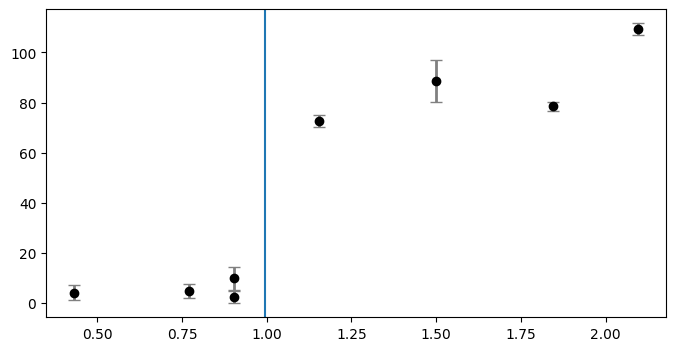

In [252]:
filter_pivots = np.array([f.pivot / 10000.0 for f in active_filters]) 

plt.figure(figsize=(8, 4))
# Plot observed broadband data points
plt.errorbar(filter_pivots, obs_fluxes, yerr=obs_errors, fmt='o', color='black', 
             ecolor='gray', elinewidth=2, capsize=4, label='Observed Photometry')

plt.axvline(0.995390596)

In [250]:
filter_pivots

array([0.90229222, 1.15430093, 1.50074549, 1.84522065, 2.09553078,
       0.43188281, 0.76923043, 0.90326832])

Running Photometric MCMC chain with 32 walkers for 1500 steps...


100%|██████████| 1500/1500 [01:03<00:00, 23.47it/s]



--- Fit Results ---
A = 98.588 (+1.092, -2.823)
$\beta$ = 0.071 (+0.009, -0.014)
$F_{\rm Ly\alpha}$ = 21.064 (+19.517, -16.996)
$\sigma_{\rm Ly\alpha}$ = 44.467 (+38.003, -31.316)
z = 7.188 (+0.000, -0.000)
LyA Detection S/N = 1.38


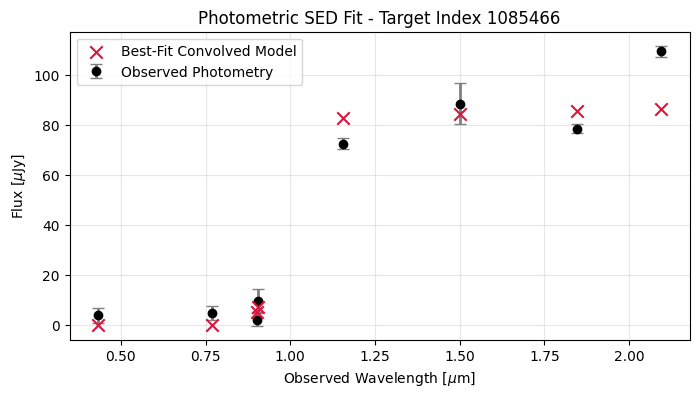

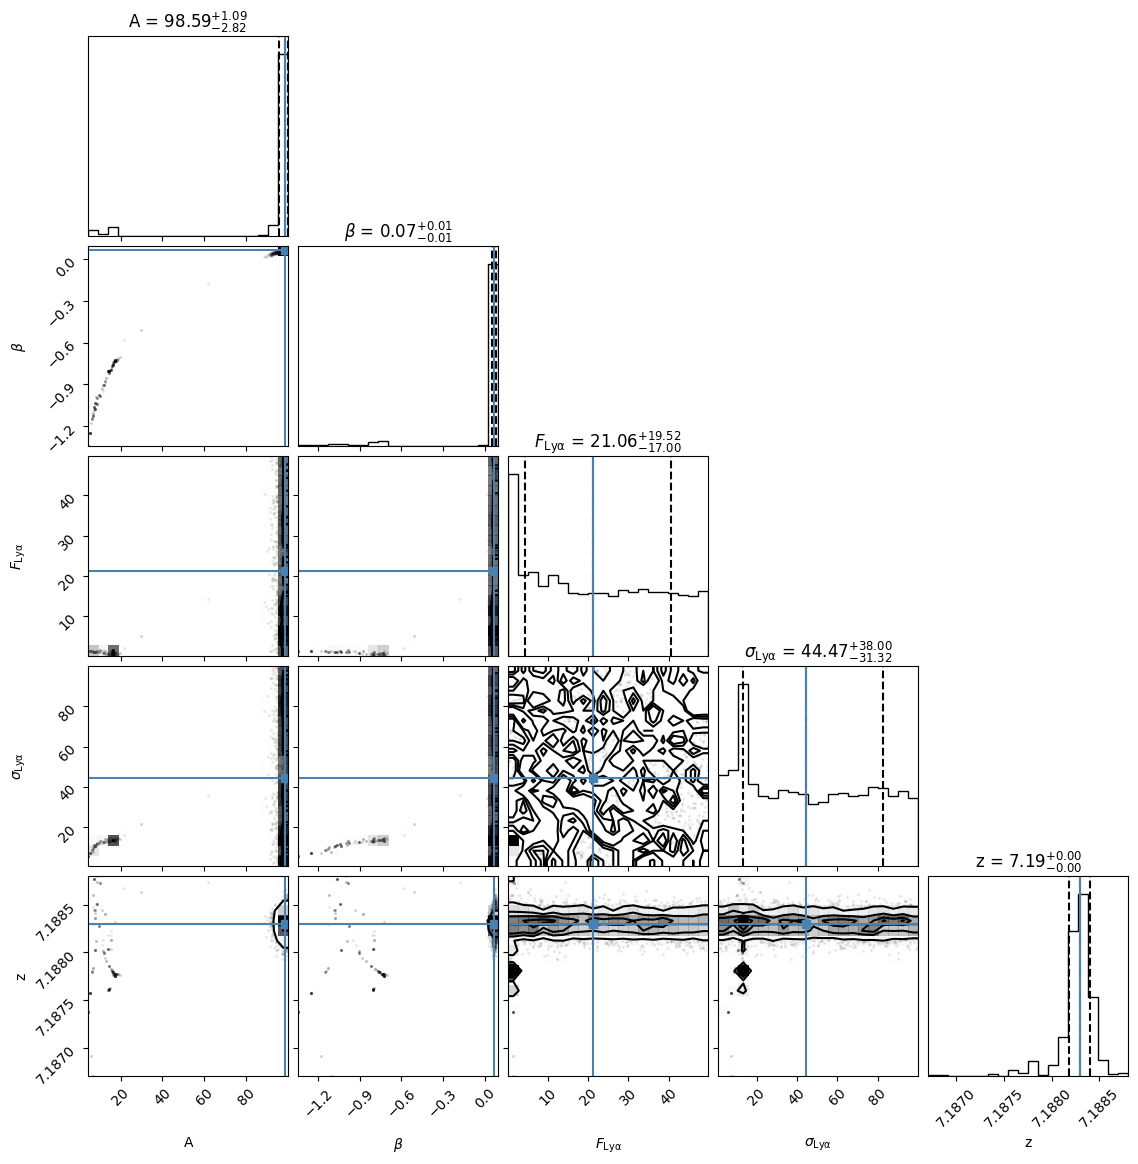

In [251]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import eazy.igm
import eazy.filters

# ==========================================
# 0. CHOOSE A TARGET ROW & EXTRACT FILTERS
# ==========================================
# Let's pick a single row from your dataframe to fit (e.g., index 0)
# row_id = 194756
# target_row = akins_115[akins_115['id'] == row_id][0]

# CHANGE THIS BETWEEN CATALOGS
# active_filters = [filter_file[364], filter_file[365], filter_file[375], filter_file[239]]

# Extract observed data arrays for this target row
# CHANGE THIS BETWEEN CATALOGS
# obs_fluxes = np.array([target_row['flux_814'], target_row['flux_115'], target_row['flux_150'], target_row['flux_277']])
# obs_errors = np.array([target_row['err_814'], target_row['err_115'], target_row['err_150'], target_row['err_277']])


# Extract target-specific EAZY priors for this row
# CHANGE THIS BETWEEN CATALOGS
# z_eazy = target_row['z_gal_med']
# z_err_eazy = (target_row['z_gal_u68'] - target_row['z_gal_l68'])/2

z_eazy = 7.1883
z_err_eazy = 0.0001

# ==========================================
# 1. SETUP MODIFIED PROBABILITY FUNCTIONS
# ==========================================
def log_probability_photometry(theta):
    lp = log_prior_photometry(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_photometry(theta)

def forward_model_photometry(theta, active_filters):
    """
    Generates synthetic photometric fluxes by computing a high-resolution 
    intrinsic model, applying IGM absorption, and integrating through filters.
    
    Parameters:
    -----------
    theta : list or array
        The 5 free parameters: [A, beta, F_Lya, sigma_Lya, z]
    active_filters : list
        List of EAZY filter objects parsed from filters.res
        
    Returns:
    --------
    np.array
        Integrated model fluxes matching the order of active_filters (microJanskies).
    """
    A, beta, F_Lya, sigma_Lya, z = theta
    
    # 1. Setup Intrinsic Model (Everything evaluated in rest-frame Angstroms)
    lambda_Lya_rest = 1215.67
    
    # Map our fixed, fine observed-frame wavelength grid into the rest frame
    wave_rest = fine_model_wave / (1.0 + z)
    
    # Continuum component: Power law normalized at lambda_0 (1700 A)
    flux_cont = A * (wave_rest / lambda_0)**beta
    
    # Line component: Gaussian profile centered at Lyman-alpha
    flux_line = (F_Lya / (np.sqrt(2 * np.pi) * sigma_Lya)) * \
                np.exp(-0.5 * ((wave_rest - lambda_Lya_rest) / sigma_Lya)**2)
    
    f_int = flux_cont + flux_line
    
    # 2. Apply IGM Transmission (Inoue 2014) in the observed frame
    t_igm = igm.full_IGM(z, fine_model_wave)
    f_trans = f_int * t_igm  
    
    # 3. Synthetic Photometry via Filter Profile Integration
    model_fluxes = []
    for filt in active_filters:
        # Interpolate the filter's throughput profile onto our fine internal wavelength grid
        R = np.interp(fine_model_wave, filt.wave, filt.throughput, left=0.0, right=0.0)
        
        # Safety check: if filter footprint falls entirely outside our grid limits
        if np.sum(R) == 0:
            model_fluxes.append(0.0)
            continue
            
        # Photon-weighted integration matching standard detector response
        top = np.trapz(f_trans * R * fine_model_wave, fine_model_wave)
        bottom = np.trapz(R * fine_model_wave, fine_model_wave)
        
        model_fluxes.append(top / bottom)
        
    return np.array(model_fluxes)

def log_likelihood_photometry(theta):
    """
    Computes the Gaussian log-likelihood by comparing the integrated 
    synthetic model fluxes to the observed broadband photometric data points.
    """
    # Evaluate the forward model fluxes for the current parameter step
    model_fluxes = forward_model_photometry(theta, active_filters)
    
    # Standard chi-squared calculation over the available filter bands
    chi2 = np.sum(((obs_fluxes - model_fluxes) / obs_errors)**2)
    
    return -0.5 * chi2

def log_prior_photometry(theta):
    A, beta, F_Lya, sigma_Lya, z = theta
    
    # Apply a hard boundary to isolate the high-z regime entirely
    if not (6.5 < z < 11.0):
        return -np.inf
        
    if not (0.0 < A < 100.0 and -4.0 < beta < 3.0 and 0.0 <= F_Lya < 50.0 and 1.0 < sigma_Lya < 100.0):
        return -np.inf
        
    # Apply your exact Gaussian prior constraint
    log_z_prior = -0.5 * ((z - z_eazy) / z_err_eazy)**2
    return log_z_prior

# ==========================================
# 4. RUN EMCEE SAMPLER (UPDATED FOR 5 PARAMETERS)
# ==========================================
ndim = 5  # Changed to 5: A, beta, F_Lya, sigma_Lya, z
nwalkers = 32
nsteps = 1500

# Guess starting values: [A, beta, F_Lya, sigma_Lya, z]
# We use the median flux for A, and the EAZY peak for z
initial_guess = [np.nanmedian(obs_fluxes), -1.5, 1.0, 15.0, z_eazy]

# Create a small proportional ball around the initial guess
pos = np.zeros((nwalkers, ndim))
for i in range(ndim):
    spread = max(abs(initial_guess[i]) * 0.05, 1e-2)
    pos[:, i] = initial_guess[i] + spread * np.random.randn(nwalkers)

print(f"Running Photometric MCMC chain with {nwalkers} walkers for {nsteps} steps...")
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability_photometry)

# Run MCMC
sampler.run_mcmc(pos, nsteps, progress=True)

# ==========================================
# 5. POST-PROCESSING & PLOTTING (UPDATED)
# ==========================================
# Discard burn-in phase
flat_samples = sampler.get_chain(discard=300, thin=10, flat=True)

# Extract best-fit parameters (median values)
best_fit_theta = np.median(flat_samples, axis=0)
labels = ["A", r"$\beta$", r"$F_{\rm Ly\alpha}$", r"$\sigma_{\rm Ly\alpha}$", "z"]

print("\n--- Fit Results ---")
for i in range(ndim):
    p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    print(f"{labels[i]} = {p50:.3f} (+{p84-p50:.3f}, -{p50-p16:.3f})")

# Calculate Signal-to-Noise ratio threshold defined in paper
f_lya_mcmc = flat_samples[:, 2]
snr = np.median(f_lya_mcmc) / np.std(f_lya_mcmc)
print(f"LyA Detection S/N = {snr:.2f}")

# --- Plot 1: Discrete Photometric SED Fit ---
# Calculate the pivot wavelengths of your filters to map the X axis (microns)
filter_pivots = np.array([f.pivot / 10000.0 for f in active_filters]) 

plt.figure(figsize=(8, 4))
# Plot observed broadband data points
plt.errorbar(filter_pivots, obs_fluxes, yerr=obs_errors, fmt='o', color='black', 
             ecolor='gray', elinewidth=2, capsize=4, label='Observed Photometry')

# Plot the model equivalent flux points derived through filter integration
best_model_fluxes = forward_model_photometry(best_fit_theta, active_filters)
plt.scatter(filter_pivots, best_model_fluxes, color='crimson', s=80, marker='x', 
            zorder=3, label='Best-Fit Convolved Model')

plt.xlabel(r'Observed Wavelength [$\mu$m]')
plt.ylabel(r'Flux [$ \mu $Jy]')
plt.title(f"Photometric SED Fit - Target Index {row_id}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Plot 2: The Posterior Corner Plot ---
fig = corner.corner(
    flat_samples, 
    labels=labels, 
    truths=best_fit_theta,
    quantiles=[0.16, 0.50, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12}
)
plt.show()

In [213]:
from grizli import utils
from astropy.utils.data import download_file

version = "v4.4" # Updated September 5, 2025.  Include all public spectra even without redshift / line fits

CACHE_DOWNLOADS = True
URL_PREFIX = "https://zenodo.org/records/15472354/files/"

# --- Load MSAEXP emission line catalog ---
table_url = f"{URL_PREFIX}/dja_msaexp_emission_lines_{version}.csv.gz"
spectra = utils.read_catalog(download_file(table_url, cache=CACHE_DOWNLOADS), format='csv')

In [220]:
from astropy.coordinates import SkyCoord
import astropy.units as u

def find_msaexp_file_by_coor(ra_target, dec_target, catalog):
    """
    Finds the closest matching target in the msaexp catalog by RA and Dec,
    and returns its S3 bucket folder root and spec.fits filename.
    """
    # 1. Convert the entire catalog coordinates into SkyCoord structures
    catalog_coords = SkyCoord(ra=catalog['ra']*u.deg, dec=catalog['dec']*u.deg)
    target_coord = SkyCoord(ra=ra_target*u.deg, dec=dec_target*u.deg)
    
    # 2. Match coordinates (finds the absolute closest index)
    idx, d2d, _ = target_coord.match_to_catalog_sky(catalog_coords)
    
    # Extract the matching row
    match_row = catalog[idx]
    
    print(f"Closest match found at separation: {d2d.arcsec[0]:.3f} arcsec")
    if d2d.arcsec[0] > 1.0:
        print("Warning: The closest target is more than 1 arcsecond away. Verify coordinates.")
        
    # 3. Pull the tracking IDs needed to build the filename
    # Typically, msaexp catalogs contain 'root' and 'id' columns
        
    return match_row

find_msaexp_file_by_coor(ra_target=189.08348, dec_target=62.202583, catalog=spectra)

Closest match found at separation: 0.020 arcsec


file,srcid,ra,dec,grating,filter,effexptm,nfiles,dataset,msamet,msaid,msacnf,dithn,slitid,root,npix,ndet,wmin,wmax,wmaxsn,sn10,flux10,err10,sn50,flux50,err50,sn90,flux90,err90,xstart,ystart,xsize,ysize,slit_pa,pa_v3,srcypix,profcen,profsig,ctime,version,exptime,contchi2,dof,fullchi2,line_ariii_7138,line_ariii_7138_err,line_ariii_7753,line_ariii_7753_err,line_bra,line_bra_err,line_brb,line_brb_err,line_brd,line_brd_err,line_brg,line_brg_err,line_hb,line_hb_err,line_hd,line_hd_err,line_hei_1083,line_hei_1083_err,line_hei_3889,line_hei_3889_err,line_hei_5877,line_hei_5877_err,line_hei_7065,line_hei_7065_err,line_hei_8446,line_hei_8446_err,line_heii_4687,line_heii_4687_err,line_hg,line_hg_err,line_lya,line_lya_err,line_mgii,line_mgii_err,line_neiii_3867,line_neiii_3867_err,line_neiii_3968,line_neiii_3968_err,line_nev_3346,line_nev_3346_err,line_nevi_3426,line_nevi_3426_err,line_niii_1750,line_niii_1750_err,line_oi_6302,line_oi_6302_err,line_oii,line_oii_7325,line_oii_7325_err,line_oii_err,line_oiii,line_oiii_1663,line_oiii_1663_err,line_oiii_4363,line_oiii_4363_err,line_oiii_4959,line_oiii_4959_err,line_oiii_5007,line_oiii_5007_err,line_oiii_err,line_pa10,line_pa10_err,line_pa8,line_pa8_err,line_pa9,line_pa9_err,line_paa,line_paa_err,line_pab,line_pab_err,line_pad,line_pad_err,line_pag,line_pag_err,line_pfb,line_pfb_err,line_pfd,line_pfd_err,line_pfe,line_pfe_err,line_pfg,line_pfg_err,line_sii,line_sii_err,line_siii_9068,line_siii_9068_err,line_siii_9531,line_siii_9531_err,spl_0,spl_0_err,spl_1,spl_10,spl_10_err,spl_11,spl_11_err,spl_12,spl_12_err,spl_13,spl_13_err,spl_14,spl_14_err,spl_15,spl_15_err,spl_16,spl_16_err,spl_17,spl_17_err,spl_18,spl_18_err,spl_19,spl_19_err,spl_1_err,spl_2,spl_20,spl_20_err,spl_21,spl_21_err,spl_22,spl_22_err,spl_2_err,spl_3,spl_3_err,spl_4,spl_4_err,spl_5,spl_5_err,spl_6,spl_6_err,spl_7,spl_7_err,spl_8,spl_8_err,spl_9,spl_9_err,zline,line_civ_1549,line_civ_1549_err,line_h10,line_h10_err,line_h11,line_h11_err,line_h12,line_h12_err,line_h7,line_h7_err,line_h8,line_h8_err,line_h9,line_h9_err,line_ha,line_ha_err,line_hei_6680,line_hei_6680_err,line_heii_1640,line_heii_1640_err,line_nii_6549,line_nii_6549_err,line_nii_6584,line_nii_6584_err,line_oii_7323,line_oii_7323_err,line_oii_7332,line_oii_7332_err,line_sii_6717,line_sii_6717_err,line_sii_6731,line_sii_6731_err,line_siii_6314,line_siii_6314_err,escale0,escale1,line_ciii_1906,line_ciii_1906_err,line_niv_1487,line_niv_1487_err,line_pah_3p29,line_pah_3p29_err,line_pah_3p40,line_pah_3p40_err,eqw_ariii_7138,eqw_ariii_7753,eqw_bra,eqw_brb,eqw_brd,eqw_brg,eqw_ciii_1906,eqw_civ_1549,eqw_ha_nii,eqw_hb,eqw_hd,eqw_hei_1083,eqw_hei_3889,eqw_hei_5877,eqw_hei_7065,eqw_hei_8446,eqw_heii_1640,eqw_heii_4687,eqw_hg,eqw_lya,eqw_mgii,eqw_neiii_3867,eqw_neiii_3968,eqw_nev_3346,eqw_nevi_3426,eqw_niii_1750,eqw_niv_1487,eqw_oi_6302,eqw_oii,eqw_oii_7325,eqw_oiii,eqw_oiii_1663,eqw_oiii_4363,eqw_oiii_4959,eqw_oiii_5007,eqw_pa10,eqw_pa8,eqw_pa9,eqw_paa,eqw_pab,eqw_pad,eqw_pag,eqw_pfb,eqw_pfd,eqw_pfe,eqw_pfg,eqw_sii,eqw_siii_9068,eqw_siii_9531,line_ha_nii,line_ha_nii_err,eqw_h10,eqw_h11,eqw_h12,eqw_h7,eqw_h8,eqw_h9,eqw_ha,eqw_hei_6680,eqw_nii_6549,eqw_nii_6584,eqw_oii_7323,eqw_oii_7332,eqw_sii_6717,eqw_sii_6731,eqw_siii_6314,sn_line,ztime,line_ci_9850,line_ci_9850_err,line_feii_11128,line_feii_11128_err,line_pii_11886,line_pii_11886_err,line_feii_12570,line_feii_12570_err,eqw_ci_9850,eqw_feii_11128,eqw_pii_11886,eqw_feii_12570,line_feii_16440,line_feii_16440_err,line_feii_16877,line_feii_16877_err,line_brf,line_brf_err,line_feii_17418,line_feii_17418_err,line_bre,line_bre_err,line_feii_18362,line_feii_18362_err,eqw_feii_16440,eqw_feii_16877,eqw_brf,eqw_feii_17418,eqw_bre,eqw_feii_18362,valid,objid,z_best,ztype,z_prism,z_grating,phot_correction,phot_flux_radius,phot_dr,file_phot,id_phot,phot_mag_auto,phot_f090w_tot_1,phot_f090w_etot_1,phot_f115w_tot_1,phot_f115w_etot_1,phot_f150w_tot_1,phot_f150w_etot_1,phot_f200w_tot_1,phot_f200w_etot_1,phot_f277w_tot_1,phot_f277w_etot_1,phot_f

In [223]:
with fits.open('https://s3.amazonaws.com/msaexp-nirspec/extractions/gdn-fujimoto-v4/gdn-fujimoto-v4_g140m-f070lp_4762_33609.spec.fits') as hdul:
    spec_data = Table(hdul['SPEC1D'].data)

spec_data

wave,flux,err,sky,path_corr,npix,flux_sum,profile_sum,var_sum
float64,float64,float64,float64,float64,float64,float64,float64,float64
0.55,nan,nan,nan,nan,0.0,0.0,0.0,0.0
0.5506000000000001,nan,nan,nan,nan,0.0,0.0,0.0,0.0
0.5512000000000001,nan,nan,nan,nan,0.0,0.0,0.0,0.0
0.5518000000000002,nan,nan,nan,nan,0.0,0.0,0.0,0.0
0.5524000000000002,nan,nan,nan,nan,0.0,0.0,0.0,0.0
0.5530000000000003,nan,nan,nan,nan,0.0,0.0,0.0,0.0
0.5536000000000003,nan,nan,nan,nan,0.0,0.0,0.0,0.0
0.5542000000000004,nan,nan,nan,nan,0.0,0.0,0.0,0.0
0.5548000000000004,nan,nan,nan,nan,0.0,0.0,0.0,0.0


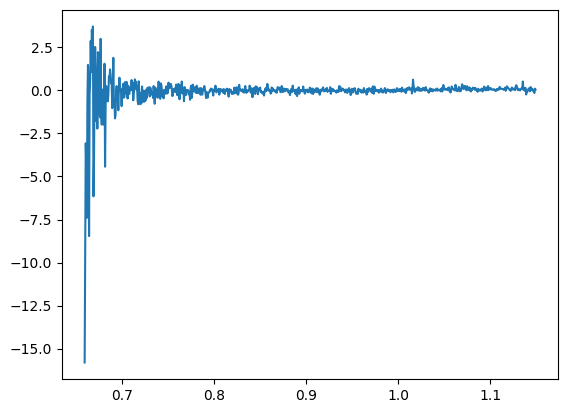

In [226]:
plt.figure()
plt.plot(spec_data['wave'][0:1000], spec_data['flux'][0:1000])

In [256]:
kokorev_phot[kokorev_phot['field'] == 'gds']

id,field,ra,dec,f090w_flux,f090w_fluxerr,f105w_flux,f105w_fluxerr,f115w_flux,f115w_fluxerr,f115wn_flux,f115wn_fluxerr,f125w_flux,f125w_fluxerr,f140w_flux,f140w_fluxerr,f150w_flux,f150w_fluxerr,f150wn_flux,f150wn_fluxerr,f160w_flux,f160w_fluxerr,f200w_flux,f200w_fluxerr,f200wn_flux,f200wn_fluxerr,f277w_flux,f277w_fluxerr,f356w_flux,f356w_fluxerr,f410m_flux,f410m_fluxerr,f435w_flux,f435w_fluxerr,f444w_flux,f444w_fluxerr,f475w_flux,f475w_fluxerr,f606w_flux,f606w_fluxerr,f775w_flux,f775w_fluxerr,f814w_flux,f814w_fluxerr,f606wu_flux,f606wu_fluxerr,f850lp_flux,f850lp_fluxerr,f110w_flux,f110w_fluxerr,f182m_flux,f182m_fluxerr,f210m_flux,f210m_fluxerr,f150w2-f162m_flux,f150w2-f162m_fluxerr,f250m_flux,f250m_fluxerr,f300m_flux,f300m_fluxerr,f335m_flux,f335m_fluxerr,f350lpu_flux,f350lpu_fluxerr,f430m_flux,f430m_fluxerr,f460m_flux,f460m_fluxerr,f480m_flux,f480m_fluxerr,f814wu_flux,f814wu_fluxerr,f850lpu_flux,f850lpu_fluxerr,z_phot,z_phot16,z_phot84,av,av_err,lbol,lbol_err,muv,muv_err,r_eff_16_pix,r_eff_50_pix,r_eff_84_pix,r_eff_16_phys,r_eff_50_phys,r_eff_84_phys
,,deg,deg,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,uJy,,,,,,,,,,,,,pc,pc,pc
int32,bytes18,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1498,gds,53.05703129811096,-27.874368711785543,0.009595228375688884,0.0014187106796408958,-0.0031947563253870923,0.004869297166555722,0.012070720363163248,0.0012235843919023385,--,--,0.005146999290941913,0.005042576493760873,--,--,0.017309566542940105,0.001191768898390805,--,--,0.022166274860890983,0.006477623455741204,0.03896159796466875,0.0010504393087142781,--,--,0.18590129908374464,0.0012625003809866057,0.2098022350499215,0.001288687349887388,0.2550324711054743,0.001777716418458416,0.0045632954019029955,0.0022110684791440483,0.2639842770239923,0.0015442153270053308,--,--,0.005018017968479048,0.002733405349083892,0.014753541693546502,0.00648052698515743,0.013643992718284818,0.002000533148464232,--,--,0.01620938254782132,0.005531872309612273,--,--,--,--,--,--,--,--,--,--,--,--,--,--,0.00936379523641325,0.0033709259841667423,--,--,--,--,--,--,--,--,--,--,4.6633844,4.5675,4.7987,1.4000000000000001,0.15817640347638973,44.65977117659234,0.372406293871747,-17.049821320811702,0.11973924955900372,0.26047893524169924,0.27737143635749817,0.31367998600006103,67.67316458142663,72.06188418034793,81.49494813768518
2981,gds,53.087727002416266,-27.87124065648318,0.010349164750516365,0.0007295353613673805,0.013427501216999057,0.005215440089178583,0.011195083840098208,0.0006716769409625716,--,--,-2.1672664382239025e-05,0.004065269511230202,-0.01022305735880599,0.0177371536578551,0.011335814045916326,0.0006545379948242308,--,--,0.007985446855538224,0.005163926440105051,0.01235001353032956,0.0006435877114054711,--,--,0.028296939216220396,0.0006031258181133128,0.0582742231966499,0.0007536197977557672,0.048819506615409396,0.0008822025729825644,-0.0006756342170290194,0.0022064924931757255,0.05618472955600084,0.0008327398951955261,--,--,0.007812318998273037,0.0020777597591379923,0.019074786819242313,0.006633573980666093,0.014158488163275189,0.002225922963842245,0.008792439433268009,0.0100296491456996

In [263]:
li_spectra[(li_spectra['pid'] == 1180) | (li_spectra['pid'] == 1181) | (li_spectra['pid'] == 1286)]

pid,srcid,root,file,ra,dec,zspec,f444w_aper0.1,mu,Ndup,dup_filenames,use_dG25,lambda_v,beta_UV,M_UV,break_strength,beta_MBB,Teff,peak_wave,logL_MBB,logL_5100,L5100_LMBB,Ha_total_ew,Hb_total_ew,Balmer_dec_total,LHa_total,logLHa_total,OIII_5007_ew,LOIII_5007,logLOIII_5007,LOI_8446,logLOI_8446
int64,int64,bytes24,bytes57,float64,float64,float64,float64,float64,int64,bytes49[4],bool,float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5],float64[5]
1181,39353,jades-gdn-v4,jades-gdn-v4_prism-clear_1181_39353.spec.fits,189.2939522,62.1530911,4.8533993,59.21167860728579,1.0,1,jades-gdn-v4_prism-clear_1181_39353.spec.fits .. None,True,0.3340037763118744 .. 0.45055638551712035,-2.8276975989341735 .. -2.2489828944206236,-21.40169448852539 .. -20.584888648986816,0.33959116082195706 .. 2.6880155251331477,-- .. --,-- .. --,-- .. --,-- .. --,43.10054965881666 .. 43.18090740810435,-- .. --,433.352909301558 .. 507.36538193278517,91.00902918794051 .. 146.02704611680417,3.962929593139358 .. 5.874333007058751,1.625224494804256e+42 .. 1.7860631403666565e+42,42.21091335881116 .. 42.25189679794477,280.2458077045668 .. 366.68655563116124,9.410528814485626e+41 .. 1.0691543556083158e+42,41.97361402532239 .. 42.029040409354636,3.621721079775898e+40 .. 1.4270380453366212e+41,40.55891371418174 .. 41.154435473871445
1181,53501,jades-gdn-v4,jades-gdn-v4_prism-clear_1181_53501.spec.fits,189.2950564,62.1935722,3.43598,125.08581147733663,1.0,1,jades-gdn-v4_prism-clear_1181_53501.spec.fits .. None,True,0.31364665776491163 .. 0.3810833185911179,-1.8431981384754181 .. -1.0931048572063446,-20.18318920135498 .. -19.789146518707277,1.0632379969469774 .. 2.9675104944759902,-1.0945989310741424 .. -0.17839395999908447,4750.49990234375 .. 6239.660083007812,0.6013409000000293 .. 0.6435340000000117,43.551477122040275 .. 43.633882519011024,43.19291220836708 .. 43.23697949992592,0.38807220195990105 .. 0.4601447497939973,1034.7019664526501 .. 1129.2835481584104,133.84614341473198 .. 177.1684666389857,6.716495398354328 .. 8.331121814041229,4.029361583737725e+42 .. 4.207265981791014e+42,42.60523624147004 .. 42.623999968767734,523.5506919224063 .. 605.2980461873796,1.9771211922987428e+42 .. 2.0943663319541016e+42,42.29603328770137 .. 42.32105264712391,7.880355001579784e+40 .. 1.1227041319601334e+41,40.89654569986236 .. 41.05026494058409
1181,68797,jades-gdn-v4,jades-gdn-v4_prism-clear_1181_68797.spec.fits,189.2291371,62.1461898,5.043335,1536.556315786032,1.0,1,jades-gdn-v4_prism-clear_1181_68797.spec.fits .. None,True,0.3645576149225235 .. 0.41872466951608656,-1.2844720959663392 .. -0.9214151799678802,-21.023731231689453 .. -20.750865268707276,1.7801520436684541 .. 2.6984591918395044,-- .. --,-- .. --,-- .. --,-- .. --,44.18721601273556 .. 44.19713882210954,-- .. --,1082.9928470679065 .. 1116.0755745357599,138.157207330317 .. 149.64557265387654,13.930724937852093 .. 14.856827833363505,5.880498118659574e+43 .. 6.014361377630298e+43,43.76941411535395 .. 43.77918951946248,307.29321231180177 .. 318.46070309599344,9.657661907509161e+42 .. 9.88074977391477e+42,42.98487199767973 .. 42.994789901060024,2.1509446182073023e+42 .. 2.571840838778265e+42,42.33262922846266 .. 42.41024408526032
1181,73488,jades-gdn09-v4,jades-gdn09-v4_prism-clear_1181_73488.spec.fits,189.1973959,62.1772331,4.130943,118.74104376824587,1.0,0,None .. None,True,0.3478707253932953 .. 0.4165660709142685,-1.788509726524353 .. -1.629489243030548,-20.66112470626831 .. -20.32157506942749,0.9746292529652918 .. 1.330778230707893,-1.8469347953796387 .. -1.3120825290679932,5847.512182617187 .. 6984.5185546875,0.6746290000000138 .. 0.6962189000000266,43.83612639820049 .. 43.928645668578326,43.29760228033503 .. 43.31453983535978,0.23842290278513165 .. 0.2930515707328869,1083.2528106006532 .. 1122.8653924643145,133.80723046521993 .. 151.02180672210778,9.473989856808476 .. 10.